In [1]:
from Utils import Utils
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#from qiskit import QuantumCircuit,ClassicalRegister,QuantumRegister, transpile
#from qiskit_aer import AerSimulator
#from qiskit.visualization import plot_histogram

<h1 style="color:blue;">The Grover-Rudolph Algorithm</h1>

<h3 style="color:green;">Theorem (Rudolph-Grover)</h3>

Let $(\mathsf{A}, \rho_0, \mathcal{N})$ be an universal digital quantum computer in $\mathcal{A}_{2^n}.$ Given $\varrho: [0,1] \subset \mathbb{R} \rightarrow  [0,\infty)$, a non-negative function satisfying 
$$
\int_0^1 \varrho(x) \, dx = 1,
$$
there exists a quantum circuit $\mathsf{U} := \mathsf{U}_{\ell} \mathsf{U}_{\ell-1} \cdots \mathsf{U}_1$ of length $\ell = 2^n-1$ such that the law of the output quantum random variable $(\mathsf{A}, \mathcal{N}_{\rho_0}(\mathsf{U}))$ satisfies
$$
\mathbb{P}_{\mathcal{N}_{\rho_0}(\mathsf{U})}(\mathsf{A} = k) = \int_{\frac{k}{2^n}}^{\frac{k+1}{2^n}} \varrho(x) \, dx \quad \text{for each } k \in \mathbb{Z}_{2^n}.
$$



<span style="color:red; font-size:18px;">Example 1:

Given the following density function:

$$
\rho(x) = \begin{cases}
4x & \text{if } 0 \leq x \leq \frac{1}{2}, \\
4 - 4x & \text{if } \frac{1}{2} \leq x \leq 1.
\end{cases}
$$

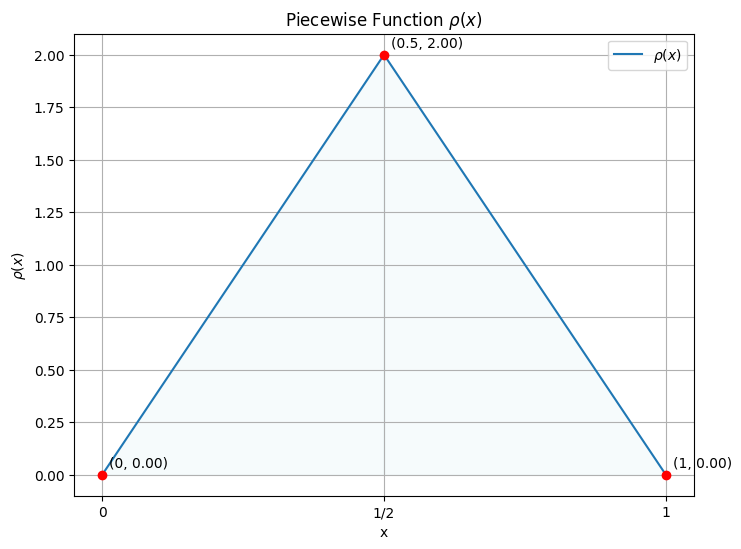

In [2]:

# Generate x values for plotting
x_values = np.linspace(0, 1, 500)  # Adjust number of points for smoother plot

# Plot the function
plt.figure(figsize=(8, 6))

# Plot the function without shading
plt.plot(x_values, Utils.f(x_values), label=r'$\rho(x)$')

# Shade the area inside the triangle
plt.fill_between(x_values, 0, Utils.f(x_values), where=(x_values >= 0) & (x_values <= 0.5), color='lightblue', alpha=0.1)
plt.fill_between(x_values, 0, Utils.f(x_values), where=(x_values > 0.5) & (x_values <= 1), color='lightblue', alpha=0.1)

# Plot points at selected nodes
nodes = [0, 0.5, 1]
for node in nodes:
    plt.scatter(node, Utils.f(np.array([node])), color='red', zorder=5)  # zorder ensures points are plotted above the filled area

    # Annotate the point with its coordinates
    plt.annotate(f'({node}, {Utils.f(np.array([node]))[0]:.2f})', (node, Utils.f(np.array([node]))[0]), textcoords="offset points", xytext=(5,5), ha='left')

plt.xlabel('x')
plt.ylabel(r'$\rho(x)$')
plt.title('Piecewise Function $\\rho(x)$')
plt.grid(True)

# Set x-axis ticks to show 0, 1/2, and 1
plt.xticks([0, 0.5, 1], ['0', '1/2', '1'])

plt.legend()
plt.show()


Now, we are going to construct the quantum circuit of the statement of Theorem, related with a unitary matrix $\mathsf{U},$ such that

$$
\mathbb{P}_{\rho_0}(\mathsf{A} = k) = \int_{\frac{k}{2^n}}^{\frac{k+1}{2^n}} \varrho(x) \, dx, \text{ holds for each } k \in \mathbb{Z}_{2^3},
$$

in a $(n=3)$-qubit universal digital quantum computer $(\mathsf{A},\rho_0,\mathcal{N}),$ in $\mathcal{A}_{2^3}.$


We start by consider the unitary matrix $\mathsf{U}_1 := \mathsf{I_{2^{2}}} \otimes \mathsf{R}(\theta),$ 
where 
\begin{align*}
 \theta = & \arccos \sqrt{\frac{\int_{0}^{1/2} \varrho(x) dx}{\int_{0}^{1} \varrho(x) dx}} = \arccos \sqrt{\int_{0}^{1/2} \varrho(x) dx} = \frac{\pi}{4}.
\end{align*}

Then we apply $\mathsf{U}_2:= (\mathbb{I}_{2}\otimes \mathsf{CC}^{(1)}_{0}\mathsf{R}(\theta_0)) (\mathbb{I}_{2}\otimes \mathsf{CC}^{(1)}_{1}\mathsf{R}(\theta_1)),$ 
so we need to calculate 

$$
\theta_0 := \arccos\sqrt{\frac{\int_{0}^{1/4}\rho(x) \, dx}{\int_{0}^{1/2}\rho(x) \, dx}} = \frac{\pi}
{3},$$


and

$$
\theta_1 := \arccos\sqrt{\frac{\int_{1/2}^{3/4} \rho(x) \, dx}{\int_{1/2}^{1} \rho(x) \, dx}} =\frac{\pi}
{6}.
$$

Finally we will apply
$$
\mathsf{U}_3 = \prod_{(z_{1}z_2) \in \mathbb{Z}_{2}^2} \mathsf{CC}^{(1)}_{z_{1}z_2}\mathsf{R}(\theta_{z_{1}z_2}),
$$
so we need to calculate 

$$
\theta_{00} := \arccos\sqrt{\frac{\int_{0}^{1/8}\rho(x) \, dx}{\int_{0}^{1/4}\rho(x) \, dx}} = \frac{\pi}
{3},
$$

$$
\theta_{10} := \arccos\sqrt{\frac{ \int_{1/4}^{3/8} \rho(x) \, dx}{\int_{1/4}^{1/2} \rho(x) \, dx}}=\arccos\frac{\sqrt{15}}{6},
$$


$$
\theta_{01} := \arccos \sqrt{\frac{\int_{1/2}^{5/8} \rho(x) \, dx}{\int_{1/2}^{3/4} \rho(x) \, dx}}=\arccos\frac{\sqrt{21}}{6},
$$

$$
\theta_{11} :=\arccos\sqrt{\frac{\int_{3/4}^{7/8}\rho(x) \, dx}{\int_{3/4}^{1}\rho(x) \, dx}}= \frac{\pi}
{6}.
$$

In [5]:
resultados = Utils.calcular_theta(n=3,funcion_a_integrar=Utils.int_f)
print(resultados)

[[np.float64(0.7853981633974483)], [np.float64(1.0471975511965976), np.float64(0.5235987755982989)], [np.float64(1.0471975511965976), np.float64(0.869122203007293), np.float64(0.7016741237876036), np.float64(0.5235987755982989)]]


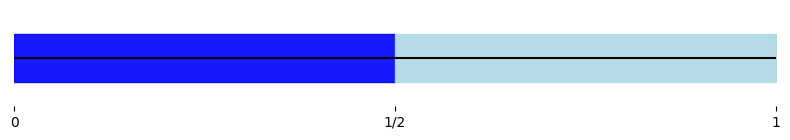

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(8, 1.5))

# Dibujar el eje x
ax.axhline(0, color='black', linewidth=1.5)
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 0.1)

# Añadir las divisiones y etiquetas
ax.set_xticks([0, 0.5, 1])
ax.set_xticklabels(['0', '1/2', '1'])
ax.set_yticks([])

# Pintar los intervalos
ax.fill_betweenx([-0.05, 0.05], 0, 0.5, color='blue', alpha=0.9, label='[0, 1/2]')
ax.fill_betweenx([-0.05, 0.05], 0.5, 1, color='lightblue', alpha=0.9, label='[1/2, 1]')

# Ajustar los márgenes
ax.set_frame_on(False)
#ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()

# Mostrar el gráfico
plt.show()


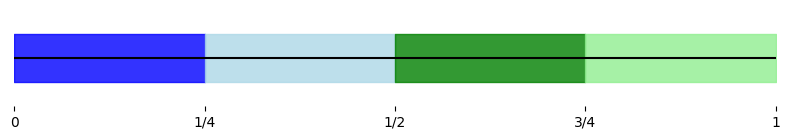

In [15]:
# Reimportar las bibliotecas necesarias
import matplotlib.pyplot as plt

# Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(8, 1.5))

# Dibujar el eje x
ax.axhline(0, color='black', linewidth=1.5)
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 0.1)

# Añadir las divisiones y etiquetas
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xticklabels(['0', '1/4', '1/2', '3/4', '1'])
ax.set_yticks([])

# Pintar los intervalos
ax.fill_betweenx([-0.05, 0.05], 0, 0.25, color='blue', alpha=0.8, label='[0, 1/4]')
ax.fill_betweenx([-0.05, 0.05], 0.25, 0.5, color='lightblue', alpha=0.8, label='[1/4, 1/2]')
ax.fill_betweenx([-0.05, 0.05], 0.5, 0.75, color='green', alpha=0.8, label='[1/2, 3/4]')
ax.fill_betweenx([-0.05, 0.05], 0.75, 1, color='lightgreen', alpha=0.8, label='[3/4, 1]')

# Ajustar los márgenes
ax.set_frame_on(False)
#ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()

# Mostrar el gráfico
plt.show()


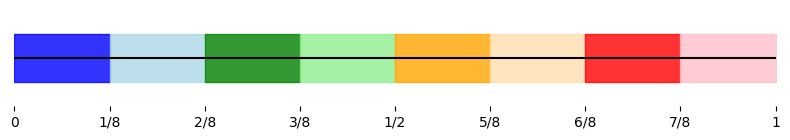

In [18]:
# Reimportar las bibliotecas necesarias
import matplotlib.pyplot as plt

# Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(8, 1.5))

# Dibujar el eje x
ax.axhline(0, color='black', linewidth=1.5)
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 0.1)

# Añadir las divisiones y etiquetas
ax.set_xticks([0, 1/8, 2/8, 3/8, 4/8, 5/8, 6/8, 7/8, 1])
ax.set_xticklabels(['0', '1/8', '2/8', '3/8', '1/2', '5/8', '6/8', '7/8', '1'])
ax.set_yticks([])

# Pintar los intervalos
colors = ['blue', 'lightblue', 'green', 'lightgreen', 'orange', 'navajowhite', 'red', 'pink']
for i in range(8):
    ax.fill_betweenx(
        [-0.05, 0.05],
        i / 8, (i + 1) / 8,
        color=colors[i % len(colors)],
        alpha=0.8,
        label=f'[{i}/8, {(i + 1)}/8]'
    )

# Ajustar los márgenes
ax.set_frame_on(False)
plt.tight_layout()

# Mostrar el gráfico
plt.show()


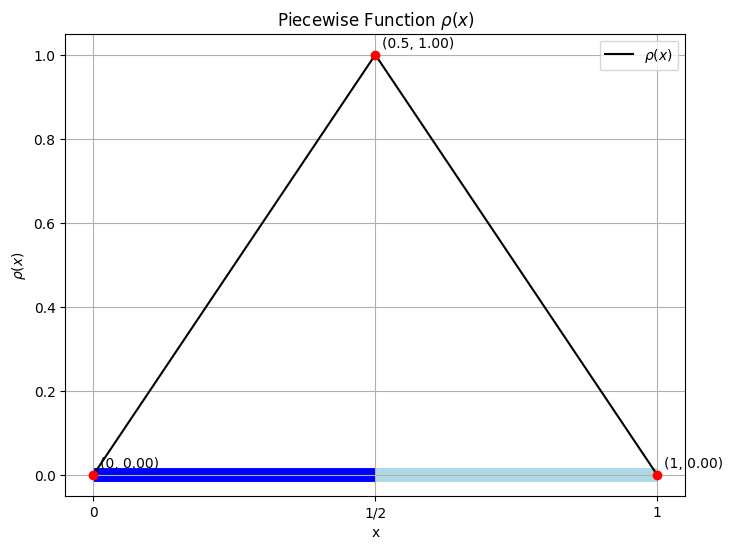

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Clase ficticia para reemplazar Utils.f si no tienes su definición
class Utils:
    @staticmethod
    def f(x):
        # Ejemplo de una función por tramos, puedes reemplazar esto con la tuya
        return np.piecewise(x, [x < 0.5, x >= 0.5], [lambda x: 2 * x, lambda x: 2 * (1 - x)])

# Generar valores de x para la función
x_values = np.linspace(0, 1, 500)

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(8, 6))

# Pintar los intervalos en el eje x
ax.hlines(0, 0, 0.5, colors='blue', linewidth=10, zorder=0)        # Intervalo [0, 1/2] azul
ax.hlines(0, 0.5, 1, colors='lightblue', linewidth=10, zorder=0)  # Intervalo [1/2, 1] azul claro

# Graficar la función
ax.plot(x_values, Utils.f(x_values), label=r'$\rho(x)$', color='black')

# Añadir puntos en nodos seleccionados
nodes = [0, 0.5, 1]
for node in nodes:
    ax.scatter(node, Utils.f(np.array([node])), color='red', zorder=5)
    ax.annotate(f'({node}, {Utils.f(np.array([node]))[0]:.2f})', 
                (node, Utils.f(np.array([node]))[0]), 
                textcoords="offset points", xytext=(5, 5), ha='left')

# Configuración del gráfico
ax.set_xlabel('x')
ax.set_ylabel(r'$\rho(x)$')
ax.set_title('Piecewise Function $\\rho(x)$')
ax.grid(True)

# Etiquetas del eje x
ax.set_xticks([0, 0.5, 1])
ax.set_xticklabels(['0', '1/2', '1'])

ax.legend()
plt.show()



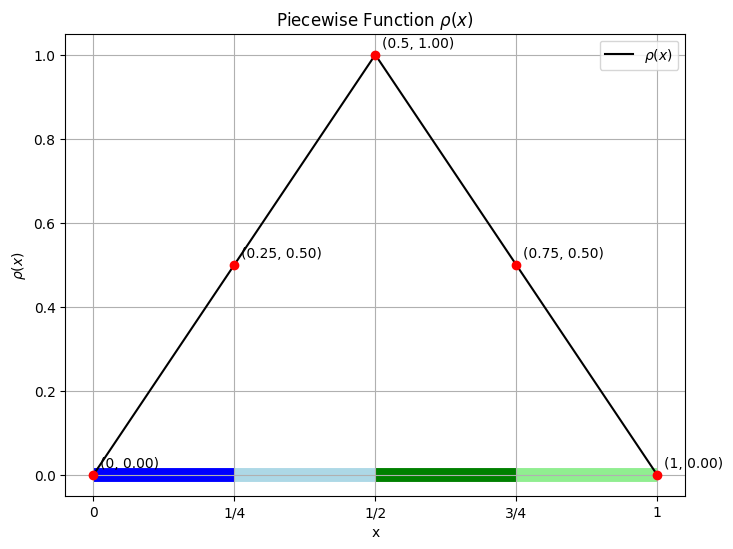

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Clase ficticia para reemplazar Utils.f si no tienes su definición
class Utils:
    @staticmethod
    def f(x):
        # Ejemplo de una función por tramos, puedes reemplazar esto con la tuya
        return np.piecewise(x, [x < 0.5, x >= 0.5], [lambda x: 2 * x, lambda x: 2 * (1 - x)])

# Generar valores de x para la función
x_values = np.linspace(0, 1, 500)

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(8, 6))

# Pintar los intervalos en el eje x con amplitud 1/4
ax.hlines(0, 0, 0.25, colors='blue', linewidth=10, zorder=0)      # Intervalo [0, 1/4] azul
ax.hlines(0, 0.25, 0.5, colors='lightblue', linewidth=10, zorder=0)   # Intervalo [1/4, 1/2] verde
ax.hlines(0, 0.5, 0.75, colors='green', linewidth=10, zorder=0)    # Intervalo [1/2, 3/4] azul
ax.hlines(0, 0.75, 1, colors='lightgreen', linewidth=10, zorder=0)     # Intervalo [3/4, 1] verde

# Graficar la función
ax.plot(x_values, Utils.f(x_values), label=r'$\rho(x)$', color='black')

# Añadir puntos en nodos seleccionados
nodes = [0, 0.25, 0.5, 0.75, 1]
for node in nodes:
    ax.scatter(node, Utils.f(np.array([node])), color='red', zorder=5)
    ax.annotate(f'({node}, {Utils.f(np.array([node]))[0]:.2f})', 
                (node, Utils.f(np.array([node]))[0]), 
                textcoords="offset points", xytext=(5, 5), ha='left')

# Configuración del gráfico
ax.set_xlabel('x')
ax.set_ylabel(r'$\rho(x)$')
ax.set_title('Piecewise Function $\\rho(x)$ ')
ax.grid(True)

# Etiquetas del eje x
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xticklabels(['0', '1/4', '1/2', '3/4', '1'])

ax.legend()
plt.show()


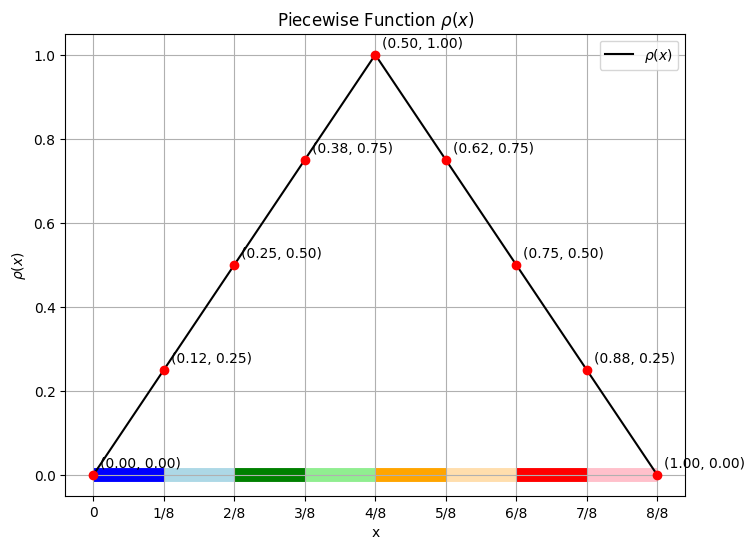

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Clase ficticia para reemplazar Utils.f si no tienes su definición
class Utils:
    @staticmethod
    def f(x):
        # Ejemplo de una función por tramos, puedes reemplazar esto con la tuya
        return np.piecewise(x, [x < 0.5, x >= 0.5], [lambda x: 2 * x, lambda x: 2 * (1 - x)])

# Generar valores de x para la función
x_values = np.linspace(0, 1, 500)

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(8, 6))

# Colores para los intervalos
colors = ['blue', 'lightblue', 'green', 'lightgreen', 'orange', 'navajowhite', 'red', 'pink']

# Pintar los intervalos en el eje x con amplitud 1/8
for i, color in enumerate(colors):
    ax.hlines(0, i / 8, (i + 1) / 8, colors=color, linewidth=10, zorder=0)

# Graficar la función
ax.plot(x_values, Utils.f(x_values), label=r'$\rho(x)$', color='black')

# Añadir puntos en nodos seleccionados
nodes = [i / 8 for i in range(9)]  # Nodos en los límites de los intervalos
for node in nodes:
    ax.scatter(node, Utils.f(np.array([node])), color='red', zorder=5)
    ax.annotate(f'({node:.2f}, {Utils.f(np.array([node]))[0]:.2f})', 
                (node, Utils.f(np.array([node]))[0]), 
                textcoords="offset points", xytext=(5, 5), ha='left')

# Configuración del gráfico
ax.set_xlabel('x')
ax.set_ylabel(r'$\rho(x)$')
ax.set_title('Piecewise Function $\\rho(x)$')
ax.grid(True)

# Etiquetas del eje x
ax.set_xticks(nodes)
ax.set_xticklabels([f'{i}/8' if i != 0 else '0' for i in range(9)])

ax.legend()
plt.show()
